In [1]:
#imports 

import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from matplotlib.ticker import LogFormatterSciNotation, MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg


# Corr Gaussian

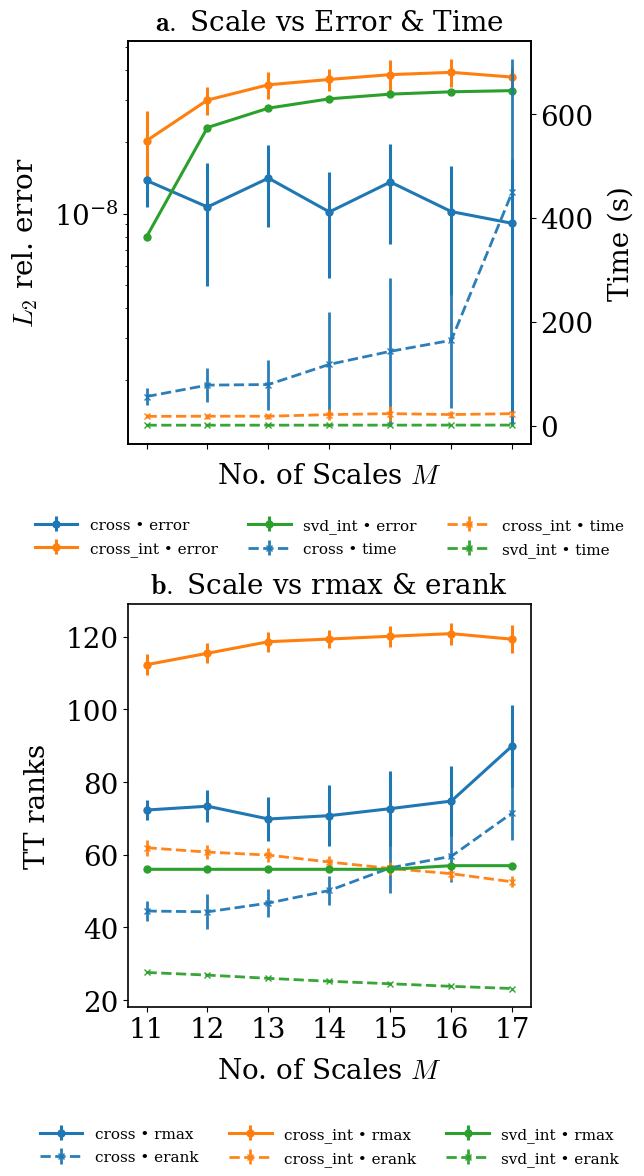

In [7]:
# corr_gaussian_results_formatted_like_wing.py
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation

# ── Style: match your reference (fonts/line widths)
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})
plt.rcParams['axes.grid'] = False

# ── Load & aggregate
CG_PATH = './data/masks/corr_gaussian_results_2.jsonl'
records = []
with open(CG_PATH, 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg(error_mean=('error','mean'),
           error_std =('error','std'),
           time_mean =('time','mean'),
           time_std  =('time','std'),
           rmax_mean =('rmax','mean'),
           rmax_std  =('rmax','std'),
           erank_mean=('erank','mean'),
           erank_std =('erank','std'))
      .reset_index()
)

methods = stats['method'].unique()
colors  = sns.color_palette('tab10', n_colors=len(methods))

# ── Figure (2×1), share x — same layout as the wing version
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(9.2, 14.2), sharex=True)
ax2 = ax1.twinx()

# --- (a) Error (log) & Time ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')

    # Error (solid)
    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', color=colors[i],
        label=f'{method} • error', capsize=0, linewidth=2.2, markersize=5
    )
    # Time (dashed)
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', color=colors[i], alpha=0.95,
        label=f'{method} • time', capsize=0, linewidth=2.0, markersize=5
    )

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_xlabel(r'No. of Scales $M$', labelpad=10)

ax1.set_ylabel(r'$L_2$ rel. error', labelpad=10)
ax2.set_ylabel('Time (s)', labelpad=10)
ax1.set_title(r"$\mathbf{a.}$ Scale vs Error & Time", pad=8)

# Make panel more square (just like the wing figure)
try:
    ax1.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the top plot (combine lines from both axes)
LEG_Y  = -0.28        # vertical offset below axis (negative = below)
N_COLS = 3            # adjust if many methods
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='upper center', bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=11, handlelength=2.8,
    labelspacing=0.6, borderpad=-3, ncol=N_COLS
)

# --- (b) rmax & erank ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    ax3.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='o', linestyle='-', color=colors[i],
        label=f'{method} • rmax', capsize=0, linewidth=2.2, markersize=5
    )
    ax3.errorbar(
        d['scale'], d['erank_mean'], yerr=d['erank_std'],
        marker='x', linestyle='--', color=colors[i], alpha=0.95,
        label=f'{method} • erank', capsize=0, linewidth=2.0, markersize=5
    )

ax3.set_xlabel(r'No. of Scales $M$', labelpad=10)
ax3.set_ylabel('TT ranks', labelpad=10)
ax3.set_title(r"$\mathbf{b.}$ Scale vs rmax & erank", pad=8)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# Make panel more square
try:
    ax3.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the bottom plot
lines3, labels3 = ax3.get_legend_handles_labels()
ax3.legend(
    lines3, labels3,
    loc='upper center', bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=11, handlelength=2.8,
    labelspacing=0.6, borderpad=0, ncol=N_COLS
)

# Thicken spines
for ax in (ax1, ax2, ax3):
    for s in ax.spines.values():
        s.set_linewidth(1.2)

# Extra bottom margin so legends have room underneath each subplot
fig.subplots_adjust(left=0.12, right=0.98, top=0.92, bottom=0.24, hspace=0.4)

# Save
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, 'corr_gaussian_results.pdf'),
            format='pdf', bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(out_dir, 'corr_gaussian_results.png'),
            dpi=200, bbox_inches='tight', facecolor='white')

plt.show()


# Masks

## 1D funciton

In [2]:
# 1) LaTeX style: serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Load & aggregate
#df = pd.read_csv('./data/mask_results.csv')
records = []
with open('./data/masks/1d_funciton.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:      # skip empty or whitespace-only lines
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)
df.to_csv('1d_records.csv',index=False)

/tmp/ipykernel_2389213/1710971567.py:119: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: weighted_error_stats(g))


Saved ./plots/1d_function.[pdf|png]


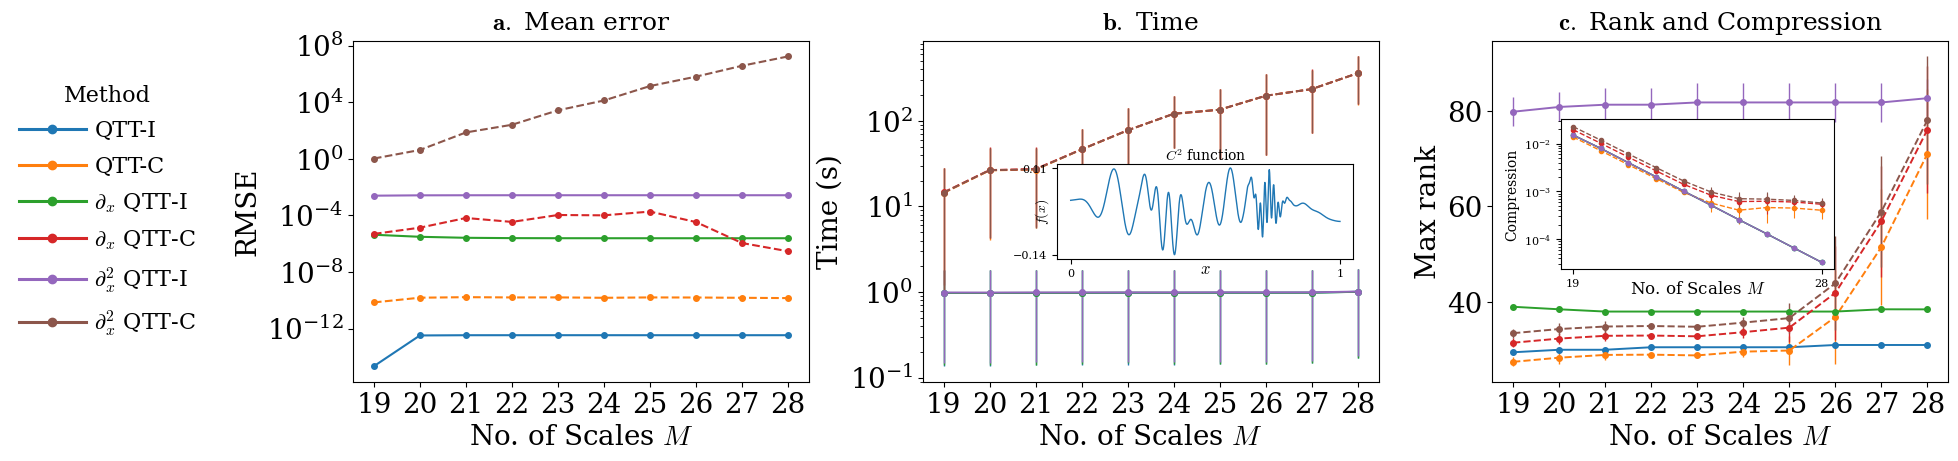

In [2]:
# make_plots_with_outside_legend.py
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterMathtext
from matplotlib.lines import Line2D

# ─────────────────────────────────────────────────────────
# Style (match your formatted version; no grid lines)
# ─────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.grid": False,
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

# ─────────────────────────────────────────────────────────
# Load data
# ─────────────────────────────────────────────────────────
CSV_PATH = "1d_records.csv"
df = pd.read_csv(CSV_PATH)

required = {"method", "scale", "error", "serror"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}. "
                     f"Found: {list(df.columns)}")

for c in ["scale", "error", "serror"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=list(required))

have_time = "time" in df.columns
have_rmax = "rmax" in df.columns
have_erank = "erank" in df.columns

# ─────────────────────────────────────────────────────────
# Method labels: normalize, order, pretty
# ─────────────────────────────────────────────────────────
base_map = {
    "d TTTI": "d QTT-I",
    "dd TTI": "dd QTT-I",
    "d cross": "d QTT-C",
    "dd cross": "dd QTT-C",
    "TTI": "QTT-I",
    "cross": "QTT-C",
    "cross_int": "QTT-C + Int",
    "qtt-tucker": "QTT-T + Int",
    "qtt_tucker": "QTT-T + Int",
    "svd_int": "QTT-SVD + Int",
}
df["method_base"] = df["method"].map(base_map).fillna(df["method"])

order_base = [
    "QTT-I", "QTT-C",
    "d QTT-I", "d QTT-C",
    "dd QTT-I", "dd QTT-C",
]
extras = [m for m in df["method_base"].unique() if m not in order_base]
order_base_final = order_base + extras
df["method_base"] = pd.Categorical(df["method_base"],
                                   categories=order_base_final,
                                   ordered=True)

def pretty_label(txt: str) -> str:
    t = str(txt).strip()
    if t.startswith("dd "):
        return r"$\partial_{x}^2$ " + t[3:]
    if t.startswith("d "):
        return r"$\partial_{x}$ " + t[2:]
    return t

df["method_pretty"] = df["method_base"].astype(str).map(pretty_label)
order_pretty = [pretty_label(x) for x in order_base_final]
df["method_pretty"] = pd.Categorical(df["method_pretty"],
                                     categories=order_pretty,
                                     ordered=True)

methods_in_order = [m for m in df["method_pretty"].cat.categories
                    if m in df["method_pretty"].unique()]

# ─────────────────────────────────────────────────────────
# Aggregations
# ─────────────────────────────────────────────────────────
def simple_stats(col: str) -> pd.DataFrame:
    if col not in df.columns:
        return pd.DataFrame()
    out = (
        df.groupby(["method", "method_base", "method_pretty", "scale"],
                   observed=True, sort=False)[col]
          .agg(["mean", "std"])
          .reset_index()
          .rename(columns={"mean": f"{col}_mean", "std": f"{col}_std"})
    )
    out = (out.replace([np.inf, -np.inf], np.nan)
              .dropna(subset=[f"{col}_mean"])
              .sort_values(["method_pretty", "scale"]))
    return out

def weighted_error_stats(group: pd.DataFrame) -> pd.Series:
    w = 1.0 / (group["serror"].values ** 2)
    x = group["error"].values
    wsum = w.sum()
    mu = np.sum(w * x) / wsum
    se = np.sqrt(1.0 / wsum)
    return pd.Series({"n": len(group), "error_wmean": mu, "error_wse": se})

# (a) Weighted error ± SE
err_stats_w = (
    df.groupby(["method", "method_base", "method_pretty", "scale"],
               observed=True, sort=False)
      .apply(lambda g: weighted_error_stats(g))
      .reset_index()
)
err_stats_w = (err_stats_w.replace([np.inf, -np.inf], np.nan)
                         .dropna(subset=["error_wmean", "error_wse"])
                         .sort_values(["method_pretty", "scale"]))

# (b) Time, (c) Max rank, and inset Compression (simple mean ± SD)
time_stats  = simple_stats("time")  if have_time  else pd.DataFrame()
rmax_stats  = simple_stats("rmax")  if have_rmax  else pd.DataFrame()
erank_stats = simple_stats("erank") if have_erank else pd.DataFrame()

# Colors
palette = plt.cm.tab10.colors
color_map = {m: palette[i % len(palette)] for i, m in enumerate(methods_in_order)}

def is_cross(base_name: str, raw_name: str) -> bool:
    t = (str(base_name) or "").lower() + " " + (str(raw_name) or "").lower()
    return ("cross" in t) or ("qtt-c" in t)

# ─────────────────────────────────────────────────────────
# f_h3 inset (NumPy version) — unchanged placement later
# ─────────────────────────────────────────────────────────
def _gauss_np(x, c, s): return np.exp(-0.5*((x - c)/s)**2)
def _chirp_np(x, f0, f1):
    phase = 2*np.pi*(f0*x + 0.5*(f1 - f0)*x**2)
    return np.sin(phase)

def f_h3_np(x, eps=1e-12, amp=1.0):
    base = (0.28*np.sin(16*np.pi*x) * _gauss_np(x, 0.20, 0.07)
          + 0.24*np.cos(44*np.pi*x) * _gauss_np(x, 0.36, 0.05)
          + 0.20*_chirp_np(x, 5, 18) * _gauss_np(x, 0.58, 0.12)
          + 0.18*np.sin(120*np.pi*x)* _gauss_np(x, 0.73, 0.03))
    bg = (0.07*np.sin(2*np.pi*1.8*x + 0.2)
        + 0.05*np.cos(2*np.pi*3.3*x + 0.9))
    def c2_bump(x, a, s, w=1.0):
        return w*np.maximum(x - a, 0.0)**3 * _gauss_np(x, a, s)
    kinks = (c2_bump(x, 0.22, 0.030,  +0.8)
           + c2_bump(x, 0.37, 0.025,  -0.6)
           + c2_bump(x, 0.61, 0.035,  +0.7)
           + c2_bump(x, 0.82, 0.022,  -0.5))
    pads = (-0.6*np.maximum(0.28 - x, 0.0)**3 * _gauss_np(x, 0.28, 0.030)
            +0.5*np.maximum(0.42 - x, 0.0)**3 * _gauss_np(x, 0.42, 0.028)
            -0.5*np.maximum(0.68 - x, 0.0)**3 * _gauss_np(x, 0.68, 0.030)
            +0.4*np.maximum(0.88 - x, 0.0)**3 * _gauss_np(x, 0.88, 0.022))
    f0 = base + bg + kinks + pads
    return amp*np.tanh(f0/2.5)

# ─────────────────────────────────────────────────────────
# Figure: 1×3 panels
# ─────────────────────────────────────────────────────────
fig, (ax_err, ax_time, ax_rmax) = plt.subplots(1, 3, figsize=(22, 4.8))

fig.subplots_adjust(
    left=0.30,    # more margin for the outside legend
    right=0.985,
    bottom=0.17,
    top=0.88,
    wspace=2.5,  # <-- increase subplot horizontal gap
    hspace=0.22   # (useful if you ever stack rows)
)

# (a) Error (weighted mean ± SE), log-y — NO legend here (we'll add outside)
for m in methods_in_order:
    g = err_stats_w.loc[err_stats_w["method_pretty"] == m].sort_values("scale")
    if g.empty:
        continue
    base = g["method_base"].iloc[0]; raw = g["method"].iloc[0]
    ls = "--" if is_cross(base, raw) else "-"
    ax_err.errorbar(
        g["scale"], g["error_wmean"], yerr=g["error_wse"],
        marker="o", linestyle=ls, color=color_map[m],
        capsize=0, elinewidth=1.1, linewidth=1.5, markersize=4
    )
ax_err.set_xlabel("No. of Scales $M$")
ax_err.set_ylabel(r"RMSE")
ax_err.set_yscale("log")
ax_err.yaxis.set_major_formatter(LogFormatterMathtext())
ax_err.xaxis.set_major_locator(MaxNLocator(integer=True))
ax_err.set_title(r"$\mathbf{a.}$ Mean error", fontsize=18, pad=8)

# (b) Time (mean ± SD), log-y — REMOVE legend here
if not time_stats.empty:
    for m in methods_in_order:
        g = time_stats.loc[time_stats["method_pretty"] == m].sort_values("scale")
        if g.empty:
            continue
        base = g["method_base"].iloc[0]; raw = g["method"].iloc[0]
        ls = "--" if is_cross(base, raw) else "-"
        ax_time.errorbar(
            g["scale"], g["time_mean"], yerr=g["time_std"],
            marker="o", linestyle=ls, color=color_map[m],
            capsize=0, elinewidth=1.0, linewidth=1.4, markersize=4
        )
ax_time.set_xlabel("No. of Scales $M$")
ax_time.set_ylabel(r"Time (s)")
ax_time.set_yscale("log")
ax_time.yaxis.set_major_formatter(LogFormatterMathtext())
ax_time.xaxis.set_major_locator(MaxNLocator(integer=True))
ax_time.set_title(r"$\mathbf{b.}$ Time", fontsize=18, pad=8)

# Inset: f_h3(x) — EXACT placement unchanged
xx = np.linspace(0, 1, 2000)
yy = f_h3_np(xx)
iw, ih = 0.65, 0.28
inset2 = ax_time.inset_axes([0.62 - iw/2, 0.36, iw, ih])  # unchanged
inset2.plot(xx, yy, lw=1.0)
inset2.set_title(r"$C^2$ function", fontsize=10, pad=2)
inset2.set_xlabel(r"$x$", fontsize=12)
inset2.xaxis.set_label_coords(0.5, -0.02)
inset2.set_ylabel(r"$f(x)$", fontsize=10)
inset2.yaxis.set_label_coords(-0.02, 0.5)
inset2.set_xticks([0.0, 1.0])
ymin, ymax = float(np.min(yy)), float(np.max(yy))
if ymin == ymax:
    ymin, ymax = ymin - 1.0, ymax + 1.0
inset2.set_yticks([np.round(ymin, 2), np.round(ymax, 2)])
inset2.tick_params(axis='both', labelsize=8)

# (c) Max rank (mean ± SD) + inset Compression
if not rmax_stats.empty:
    for m in methods_in_order:
        g = rmax_stats.loc[rmax_stats["method_pretty"] == m].sort_values("scale")
        if g.empty:
            continue
        base = g["method_base"].iloc[0]; raw = g["method"].iloc[0]
        ls = "--" if is_cross(base, raw) else "-"
        ax_rmax.errorbar(
            g["scale"], g["rmax_mean"], yerr=g["rmax_std"],
            marker="o", linestyle=ls, color=color_map[m],
            capsize=0, elinewidth=1.0, linewidth=1.4, markersize=4
        )
ax_rmax.set_xlabel("No. of Scales $M$")
ax_rmax.set_ylabel(r"Max rank")
ax_rmax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax_rmax.set_title(r"$\mathbf{c.}$ Rank and Compression", fontsize=18, pad=8)

if not erank_stats.empty:
    iw3, ih3 = 0.6, 0.44
    inset3 = ax_rmax.inset_axes([0.45 - iw3/2, 0.55 - ih3/2, iw3, ih3])  # unchanged
    for m in methods_in_order:
        g = erank_stats.loc[erank_stats["method_pretty"] == m].sort_values("scale")
        if g.empty:
            continue
        base = g["method_base"].iloc[0]; raw = g["method"].iloc[0]
        ls = "--" if is_cross(base, raw) else "-"
        inset3.errorbar(
            g["scale"], g["erank_mean"], yerr=g["erank_std"],
            marker="o", linestyle=ls, color=color_map[m],
            capsize=0, elinewidth=0.8, linewidth=1.0, markersize=3
        )
    scales_sorted = np.sort(df["scale"].unique())
    inset3.set_xticks([scales_sorted[0], scales_sorted[-1]] if len(scales_sorted) > 1
                      else [scales_sorted[0], scales_sorted[0]])
    yvals = erank_stats["erank_mean"].values
    ymin_e, ymax_e = float(np.nanmin(yvals)), float(np.nanmax(yvals))
    if ymin_e == ymax_e:
        ymin_e, ymax_e = ymin_e - 1.0, ymax_e + 1.0
    inset3.set_yticks([np.round(ymin_e, 2), np.round(ymax_e, 2)])
    if np.all(yvals > 0):
        from matplotlib.ticker import LogFormatterMathtext
        inset3.set_yscale("log")
        inset3.yaxis.set_major_formatter(LogFormatterMathtext())
    inset3.set_xlabel("No. of Scales $M$", fontsize=12, labelpad=1)
    inset3.xaxis.set_label_coords(0.5, -0.08)
    inset3.set_ylabel("Compression", fontsize=10, labelpad=3)
    inset3.tick_params(axis='both', labelsize=8)

# ─────────────────────────────────────────────────────────
# OUTSIDE-LEFT legend for methods (single legend)
# ─────────────────────────────────────────────────────────
method_handles = [
    Line2D([0], [0],
           linestyle='-', marker='o', color=color_map[m],
           markersize=6, linewidth=2.2, label=m)
    for m in methods_in_order
]

ax_err.legend(
    handles=method_handles,
    title="Method", frameon=False, fontsize=16, title_fontsize=16,
    loc='center right',
    bbox_to_anchor=(-0.30, 0.50),  # move more negative to push farther left
    handlelength=3.0,              # longer legend line
    handletextpad=0.4,             # gap between line and text
    labelspacing=0.6,              # vertical spacing between items
    borderpad=0.4                  # padding inside legend box
)

# Make room on the left for the outside legend, and keep reasonable gaps
fig.subplots_adjust(left=0.26, right=0.985, wspace=0.25, bottom=0.17, top=0.88)

# ─────────────────────────────────────────────────────────
# Save
# ─────────────────────────────────────────────────────────
os.makedirs("./plots", exist_ok=True)
fig.savefig("./plots/1d_function.pdf", bbox_inches="tight", facecolor="white")
fig.savefig("./plots/1d_function.png", dpi=200, bbox_inches="tight", facecolor="white")
print("Saved ./plots/1d_function.[pdf|png]")


## Circle Mask

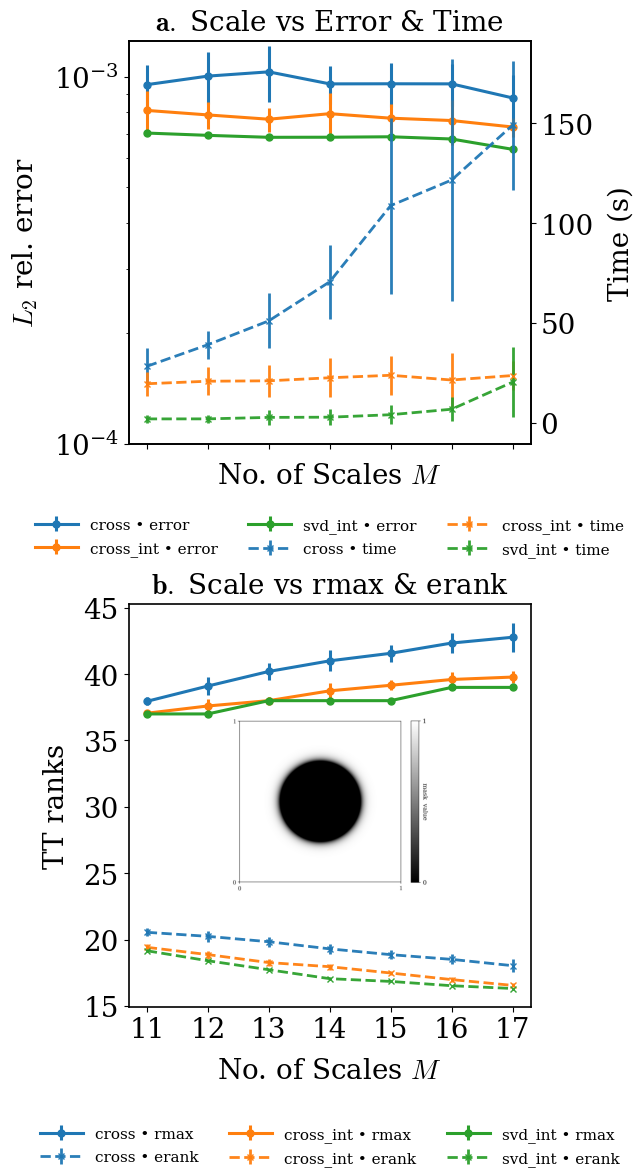

In [5]:
# circle_mask_results_formatted_like_wing.py
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg

# ── Style: match your reference (fonts/line widths)
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})
plt.rcParams['axes.grid'] = False

# ── Load & aggregate
# Change this path if your file lives elsewhere
CIRCLE_PATH = './data/masks/circle_results_lr.jsonl'
records = []
with open(CIRCLE_PATH, 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg(error_mean=('error','mean'),
           error_std =('error','std'),
           time_mean =('time','mean'),
           time_std  =('time','std'),
           rmax_mean =('rmax','mean'),
           rmax_std  =('rmax','std'),
           erank_mean=('erank','mean'),
           erank_std =('erank','std'))
      .reset_index()
)

methods = stats['method'].unique()
colors  = sns.color_palette('tab10', n_colors=len(methods))

# ── Figure (2×1), share x — same size/layout as the wing plot
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(9.2, 14.2), sharex=True)
ax2 = ax1.twinx()

# --- (a) Error (log) & Time ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    # Error (solid)
    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', color=colors[i],
        label=f'{method} • error', capsize=0, linewidth=2.2, markersize=5
    )
    # Time (dashed)
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', color=colors[i], alpha=0.95,
        label=f'{method} • time', capsize=0, linewidth=2.0, markersize=5
    )

ax1.set_yscale('log')
ax1.set_yticks([1e-4, 1e-3])  # keep explicit ticks like the wing version
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_xlabel(r'No. of Scales $M$', labelpad=10)

ax1.set_ylabel(r'$L_2$ rel. error', labelpad=10)
ax2.set_ylabel('Time (s)', labelpad=10)
ax1.set_title(r"$\mathbf{a.}$ Scale vs Error & Time", pad=8)

# Make top panel square-ish
try:
    ax1.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the top plot (combined, centered) — same placement
LEG_Y  = -0.28
N_COLS = 3
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='upper center', bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=11, handlelength=2.8,
    labelspacing=0.6, borderpad=-3, ncol=N_COLS
)

# --- (b) rmax & erank ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    ax3.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='o', linestyle='-', color=colors[i],
        label=f'{method} • rmax', capsize=0, linewidth=2.2, markersize=5
    )
    ax3.errorbar(
        d['scale'], d['erank_mean'], yerr=d['erank_std'],
        marker='x', linestyle='--', color=colors[i], alpha=0.95,
        label=f'{method} • erank', capsize=0, linewidth=2.0, markersize=5
    )

ax3.set_xlabel(r'No. of Scales $M$', labelpad=10)
ax3.set_ylabel('TT ranks', labelpad=10)
ax3.set_title(r"$\mathbf{b.}$ Scale vs rmax & erank", pad=8)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# Make bottom panel square-ish
try:
    ax3.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the bottom plot (centered) — same placement
lines3, labels3 = ax3.get_legend_handles_labels()
ax3.legend(
    lines3, labels3,
    loc='upper center', bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=11, handlelength=2.8,
    labelspacing=0.6, borderpad=0, ncol=N_COLS
)

# ── Inset image centered in the bottom panel (circle)
img_mid = mpimg.imread('./figures/circle.png')
axins = inset_axes(ax3, width="50%", height="50%", loc='center')
axins.imshow(img_mid)
axins.axis('off')
axins.set_zorder(0)
ax3.set_zorder(1)
ax3.patch.set_visible(False)

# Thicken spines
for ax in (ax1, ax2, ax3):
    for s in ax.spines.values():
        s.set_linewidth(1.2)

# Extra bottom margin so legends have room underneath each subplot
fig.subplots_adjust(left=0.12, right=0.98, top=0.92, bottom=0.24, hspace=0.4)

# Save
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, 'circle_mask_results.pdf'),
            format='pdf', bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(out_dir, 'circle_mask_results.png'),
            dpi=200, bbox_inches='tight', facecolor='white')

plt.show()


## Wing Mask

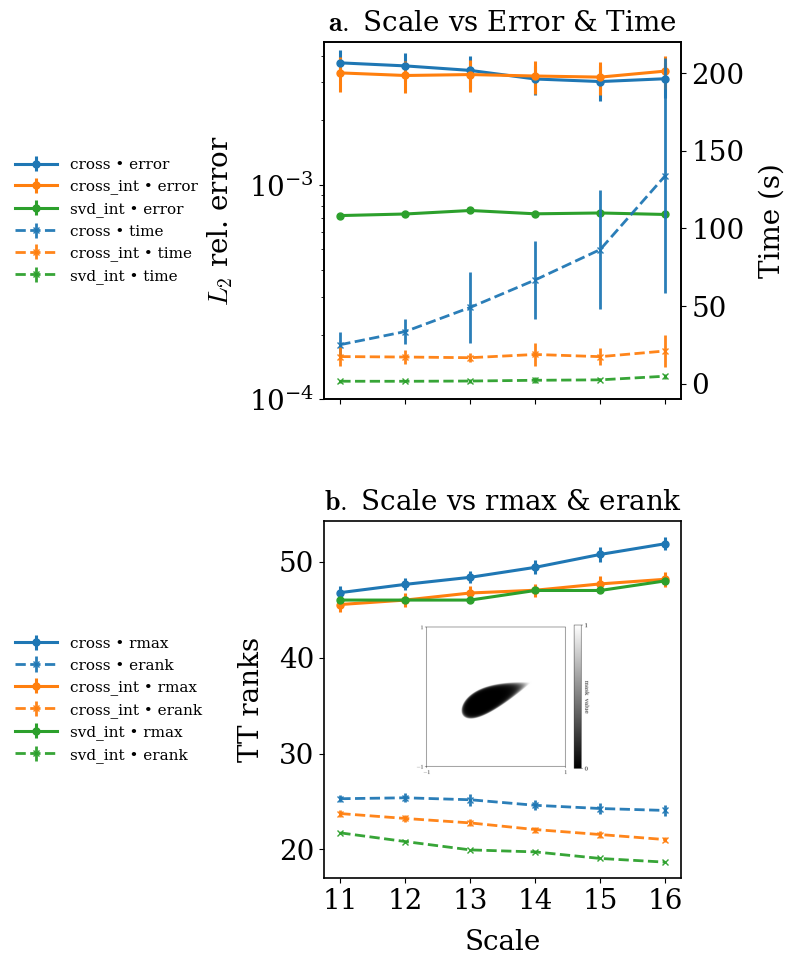

In [35]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg

# ── Style: match your reference (fonts/line widths)
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})
plt.rcParams['axes.grid'] = False

# ── Load & aggregate
records = []
with open('./data/masks/wing_results_lr.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg(error_mean=('error','mean'),
           error_std =('error','std'),
           time_mean =('time','mean'),
           time_std  =('time','std'),
           rmax_mean =('rmax','mean'),
           rmax_std  =('rmax','std'),
           erank_mean=('erank','mean'),
           erank_std =('erank','std'))
      .reset_index()
)

methods = stats['method'].unique()
colors  = sns.color_palette('tab10', n_colors=len(methods))

# ── Figure (2×1), share x
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(9.2, 10.2), sharex=True)
ax2 = ax1.twinx()

# --- (a) Error (log) & Time ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    # Error (solid)
    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', color=colors[i],
        label=f'{method} • error', capsize=0, linewidth=2.2, markersize=5
    )
    # Time (dashed)
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', color=colors[i], alpha=0.95,
        label=f'{method} • time', capsize=0, linewidth=2.0, markersize=5
    )

ax1.set_yscale('log')
ax1.set_yticks([1e-4, 1e-3])  # keep your explicit ticks
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())

ax1.set_ylabel(r'$L_2$ rel. error', labelpad=10)
ax2.set_ylabel('Time (s)', labelpad=10)
ax1.set_title(r"$\mathbf{a.}$ Scale vs Error & Time", pad=8)

# Make panel more square
try:
    ax1.set_box_aspect(1.0)
except Exception:
    pass

# Combined legend (methods+metrics) placed further LEFT (outside)
LEG_X = -0.9  # move more negative to push farther left
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='center left', bbox_to_anchor=(LEG_X, 0.5),
    frameon=False, fontsize=11, handlelength=2.8, labelspacing=0.5, borderpad=0.3
)

# --- (b) rmax & erank ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    ax3.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='o', linestyle='-', color=colors[i],
        label=f'{method} • rmax', capsize=0, linewidth=2.2, markersize=5
    )
    ax3.errorbar(
        d['scale'], d['erank_mean'], yerr=d['erank_std'],
        marker='x', linestyle='--', color=colors[i], alpha=0.95,
        label=f'{method} • erank', capsize=0, linewidth=2.0, markersize=5
    )

ax3.set_xlabel('Scale', labelpad=10)
ax3.set_ylabel('TT ranks', labelpad=10)
ax3.set_title(r"$\mathbf{b.}$ Scale vs rmax & erank", pad=8)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# Make panel more square
try:
    ax3.set_box_aspect(1.0)
except Exception:
    pass

# Bottom legend placed further LEFT (outside)
lines3, labels3 = ax3.get_legend_handles_labels()
ax3.legend(
    lines3, labels3,
    loc='center left', bbox_to_anchor=(LEG_X, 0.5),
    frameon=False, fontsize=11, handlelength=2.8, labelspacing=0.5, borderpad=0.3
)

# ── Inset image centered in the bottom panel
img_mid = mpimg.imread('./figures/wing.png')
axins = inset_axes(ax3, width="50%", height="50%", loc='center')
axins.imshow(img_mid)
axins.axis('off')
axins.set_zorder(0)
ax3.set_zorder(1)
ax3.patch.set_visible(False)

# Thicken spines
for ax in (ax1, ax2, ax3):
    for s in ax.spines.values():
        s.set_linewidth(1.2)

# Give extra room on the left for the farther-left legends
fig.subplots_adjust(left=0.36, right=0.98, top=0.92, bottom=0.10, hspace=0.34)

# Save
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, 'wing_mask_results.pdf'),
            format='pdf', bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(out_dir, 'wing_mask_results.png'),
            dpi=200, bbox_inches='tight', facecolor='white')

plt.show()


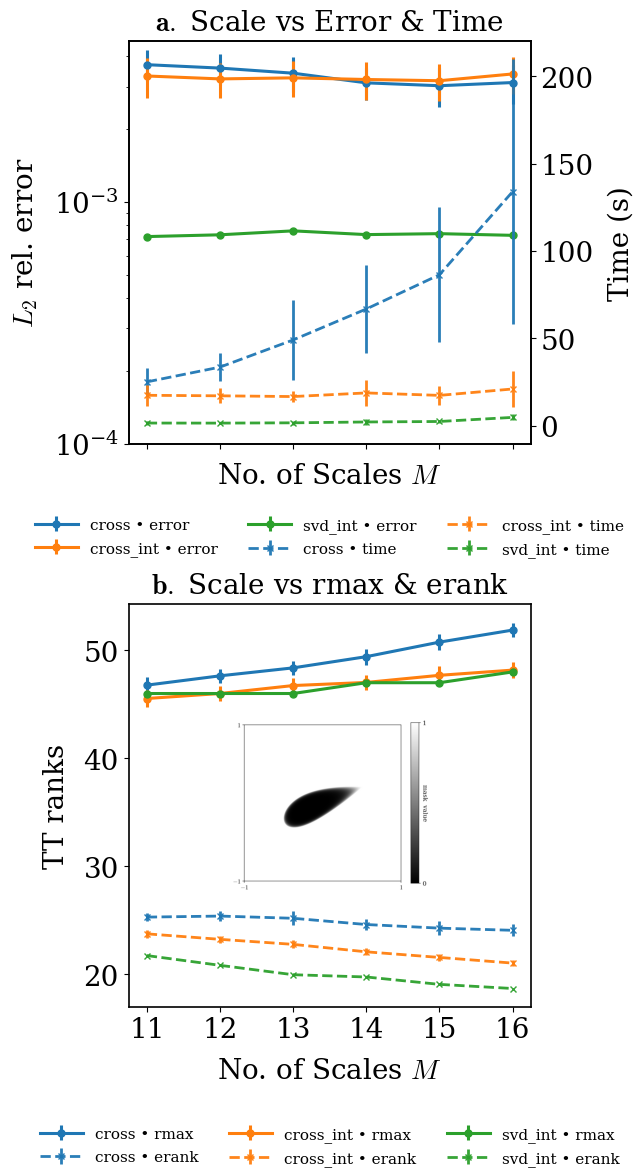

In [55]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg

# ── Style: match your reference (fonts/line widths)
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})
plt.rcParams['axes.grid'] = False

# ── Load & aggregate
records = []
with open('./data/masks/wing_results_lr.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg(error_mean=('error','mean'),
           error_std =('error','std'),
           time_mean =('time','mean'),
           time_std  =('time','std'),
           rmax_mean =('rmax','mean'),
           rmax_std  =('rmax','std'),
           erank_mean=('erank','mean'),
           erank_std =('erank','std'))
      .reset_index()
)

methods = stats['method'].unique()
colors  = sns.color_palette('tab10', n_colors=len(methods))

# ── Figure (2×1), share x
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(9.2, 14.2), sharex=True)
ax2 = ax1.twinx()

# --- (a) Error (log) & Time ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    # Error (solid)
    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', color=colors[i],
        label=f'{method} • error', capsize=0, linewidth=2.2, markersize=5
    )
    # Time (dashed)
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', color=colors[i], alpha=0.95,
        label=f'{method} • time', capsize=0, linewidth=2.0, markersize=5
    )

ax1.set_yscale('log')
ax1.set_yticks([1e-4, 1e-3])  # keep your explicit ticks
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_xlabel(r'No. of Scales $M$', labelpad=10)

ax1.set_ylabel(r'$L_2$ rel. error', labelpad=10)
ax2.set_ylabel('Time (s)', labelpad=10)
ax1.set_title(r"$\mathbf{a.}$ Scale vs Error & Time", pad=8)

# Make panel more square
try:
    ax1.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the top plot (combine lines from both axes)
LEG_Y  = -0.28       # vertical offset below the axis (negative = below)
N_COLS = 3           # adjust if you have many methods
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2, labels1 + labels2,
    loc='upper center', bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=11, handlelength=2.8,
    labelspacing=0.6, borderpad=-3, ncol=N_COLS
)

# --- (b) rmax & erank ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    ax3.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='o', linestyle='-', color=colors[i],
        label=f'{method} • rmax', capsize=0, linewidth=2.2, markersize=5
    )
    ax3.errorbar(
        d['scale'], d['erank_mean'], yerr=d['erank_std'],
        marker='x', linestyle='--', color=colors[i], alpha=0.95,
        label=f'{method} • erank', capsize=0, linewidth=2.0, markersize=5
    )

ax3.set_xlabel(r'No. of Scales $M$', labelpad=10)
ax3.set_ylabel('TT ranks', labelpad=10)
ax3.set_title(r"$\mathbf{b.}$ Scale vs rmax & erank", pad=8)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# Make panel more square
try:
    ax3.set_box_aspect(1.0)
except Exception:
    pass

# Legend BELOW the bottom plot
lines3, labels3 = ax3.get_legend_handles_labels()
ax3.legend(
    lines3, labels3,
    loc='upper center', bbox_to_anchor=(0.5, LEG_Y),
    frameon=False, fontsize=11, handlelength=2.8,
    labelspacing=0.6, borderpad=0, ncol=N_COLS
)

# ── Inset image centered in the bottom panel
img_mid = mpimg.imread('./figures/wing.png')
axins = inset_axes(ax3, width="50%", height="50%", loc='center')
axins.imshow(img_mid)
axins.axis('off')
axins.set_zorder(0)
ax3.set_zorder(1)
ax3.patch.set_visible(False)

# Thicken spines
for ax in (ax1, ax2, ax3):
    for s in ax.spines.values():
        s.set_linewidth(1.2)

# Extra bottom margin so legends have room underneath each subplot
fig.subplots_adjust(left=0.12, right=0.98, top=0.92, bottom=0.24, hspace=0.4)

# Save
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(os.path.join(out_dir, 'wing_mask_results.pdf'),
            format='pdf', bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(out_dir, 'wing_mask_results.png'),
            dpi=200, bbox_inches='tight', facecolor='white')

plt.show()


## 3D mask

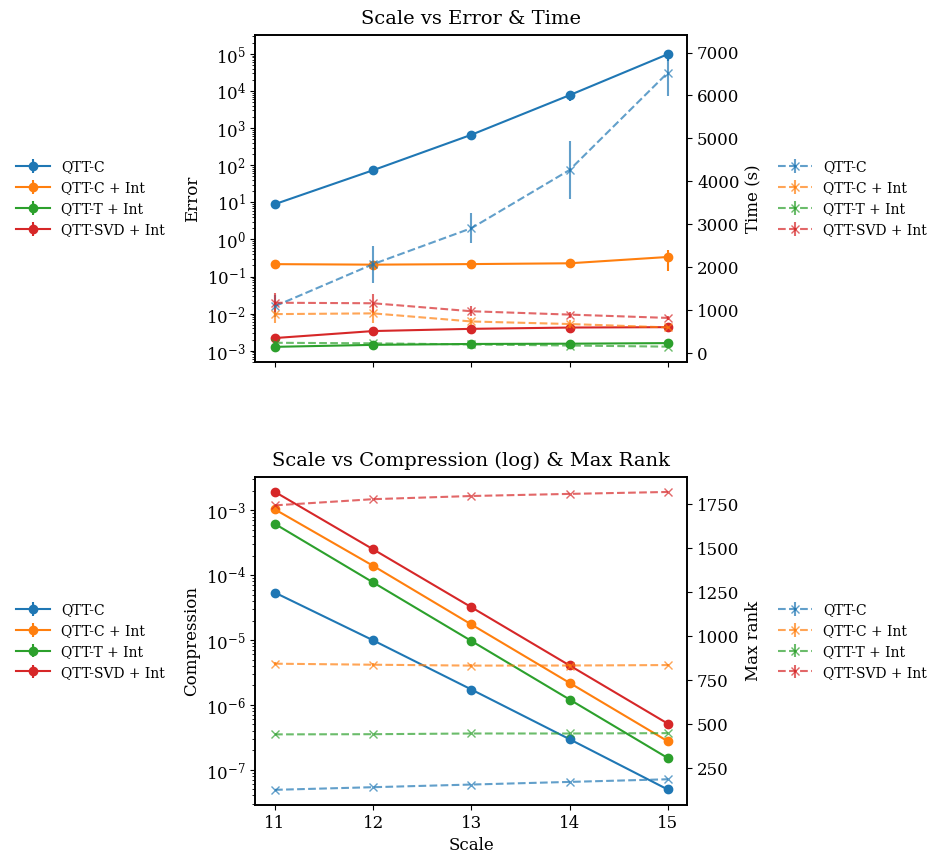

In [1]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation

# 1) LaTeX style: serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Load & aggregate
records = []
with open('./data/3d_wing_c10.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg({
          'error': ['mean', 'std'],
          'time':  ['mean', 'std'],
          'rmax':  ['mean', 'std'],
          'erank': ['mean', 'std']
      })
      .reset_index()
)

stats.columns = [
    'method','scale',
    'error_mean','error_std',
    'time_mean','time_std',
    'rmax_mean','rmax_std',
    'erank_mean','erank_std'
]

# Alias "erank" as "compression" for clarity in plotting
stats['compression_mean'] = stats['erank_mean']
stats['compression_std']  = stats['erank_std']

# --- New: pretty labels for methods ---
label_map = {
    'cross':        'QTT-C',
    'cross_int':    'QTT-C + Int',
    'qtt-tucker':   'QTT-T + Int',
    'qtt_tucker':   'QTT-T + Int',   # just in case
    'svd_int':      'QTT-SVD + Int',
}

methods = stats['method'].unique()
colors  = sns.color_palette('tab10', n_colors=len(methods))

# 3) Create 2×1 figure, share x-axis (white backgrounds)
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(8, 10), sharex=True)
fig.patch.set_facecolor('white')
ax1.set_facecolor('white'); ax3.set_facecolor('white')

ax2 = ax1.twinx()  # right axis for Time
ax4 = ax3.twinx()  # right axis for rmax
ax2.set_facecolor('white'); ax4.set_facecolor('white')

def nice_name(m):
    return label_map.get(m, m)

# --- Top: Error (log, left) & Time (right) ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    name = nice_name(method)

    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', label=f'{name} • error',
        color=colors[i], zorder=3
    )
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', label=f'{name} • time',
        color=colors[i], alpha=0.7, zorder=2
    )

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_ylabel('Error', fontsize=12)
ax2.set_ylabel('Time (s)', fontsize=12)
ax1.set_title('Scale vs Error & Time', pad=8, fontsize=14)

# Separate legends: left for Error, right for Time
err_lines, err_labels = ax1.get_legend_handles_labels()
time_lines, time_labels = ax2.get_legend_handles_labels()

def strip_suffix(labels):
    # turn "Method • error" -> "Method"
    return [lab.split('•')[0].strip() for lab in labels]

leg_err = ax1.legend(
    err_lines, strip_suffix(err_labels),
    loc='center right', bbox_to_anchor=(-0.18, 0.5),
    ncol=1, frameon=False, fontsize=10, handlelength=2.5
)
leg_time = ax2.legend(
    time_lines, strip_suffix(time_labels),
    loc='center left', bbox_to_anchor=(1.18, 0.5),
    ncol=1, frameon=False, fontsize=10, handlelength=2.5
)

# --- Bottom: Compression (log, left) & Max rank (right) ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    name = nice_name(method)

    ax3.errorbar(
        d['scale'], d['compression_mean'], yerr=d['compression_std'],
        marker='o', linestyle='-', label=f'{name} • compression',
        color=colors[i], zorder=3
    )
    ax4.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='x', linestyle='--', label=f'{name} • max rank',
        color=colors[i], alpha=0.7, zorder=2
    )

ax3.set_yscale('log')
ax3.yaxis.set_major_formatter(LogFormatterSciNotation())
ax3.set_xlabel('Scale', fontsize=12)
ax3.set_ylabel('Compression', fontsize=12)
ax4.set_ylabel('Max rank', fontsize=12)
ax3.set_title('Scale vs Compression (log) & Max Rank', pad=8, fontsize=14)

# force integer ticks on the shared x-axis
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# Separate legends: left for Compression, right for Max rank
comp_lines, comp_labels = ax3.get_legend_handles_labels()
rmax_lines, rmax_labels = ax4.get_legend_handles_labels()

leg_comp = ax3.legend(
    comp_lines, strip_suffix(comp_labels),
    loc='center right', bbox_to_anchor=(-0.18, 0.5),
    ncol=1, frameon=False, fontsize=10, handlelength=2.5
)
leg_rmax = ax4.legend(
    rmax_lines, strip_suffix(rmax_labels),
    loc='center left', bbox_to_anchor=(1.18, 0.5),
    ncol=1, frameon=False, fontsize=10, handlelength=2.5
)

# 4) Thicken spines
for ax in (ax1, ax2, ax3, ax4):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# Make room on both sides for the outside legends
fig.subplots_adjust(left=0.28, right=0.82, hspace=0.35)

# 5) Save as PDF (white background)
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(
    os.path.join(out_dir, '3d_wing_results.pdf'),
    format='pdf', bbox_inches='tight', facecolor='white'
)

plt.show()


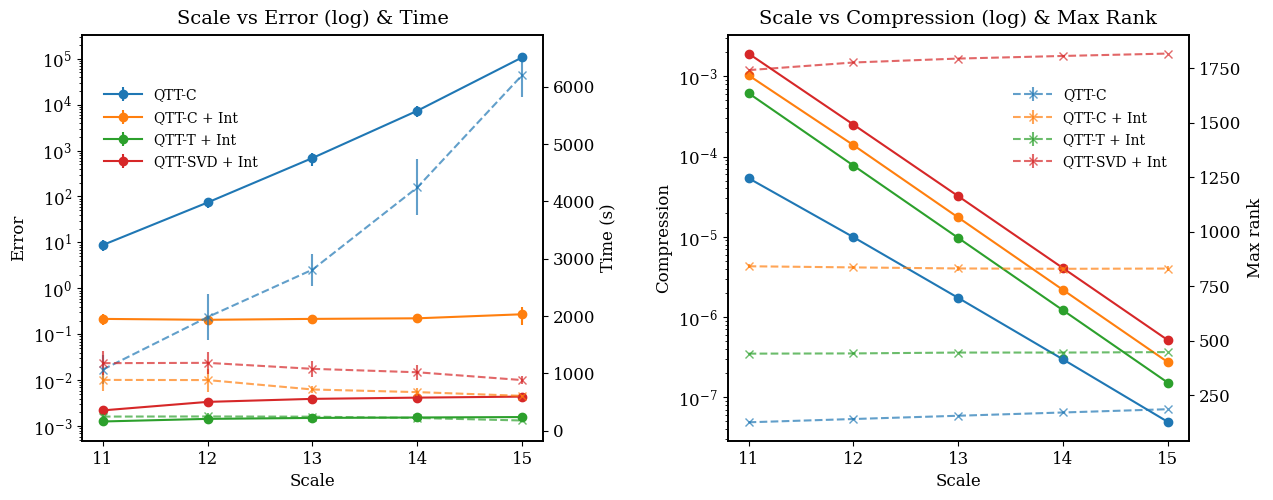

In [34]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation

# 1) LaTeX style: serif font + Computer Modern mathtext
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# 2) Load & aggregate
records = []
with open('./data/3d_wing_c10.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))

df = pd.DataFrame(records)

stats = (
    df.groupby(['method', 'scale'])
      .agg({
          'error': ['mean', 'std'],
          'time':  ['mean', 'std'],
          'rmax':  ['mean', 'std'],
          'erank': ['mean', 'std']
      })
      .reset_index()
)

stats.columns = [
    'method','scale',
    'error_mean','error_std',
    'time_mean','time_std',
    'rmax_mean','rmax_std',
    'erank_mean','erank_std'
]

# Alias "erank" as "compression"
stats['compression_mean'] = stats['erank_mean']
stats['compression_std']  = stats['erank_std']

# Pretty labels for methods
label_map = {
    'cross':        'QTT-C',
    'cross_int':    'QTT-C + Int',
    'qtt-tucker':   'QTT-T + Int',
    'qtt_tucker':   'QTT-T + Int',   # just in case
    'svd_int':      'QTT-SVD + Int',
}
def nice_name(m): return label_map.get(m, m)

methods = stats['method'].unique()
colors  = sns.color_palette('tab10', n_colors=len(methods))

# 3) 1×2 figure (side-by-side)
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(13.5, 5.2), sharex=False,
                               gridspec_kw={'wspace': 0.4})
fig.subplots_adjust(left=0.10, right=0.92, top=0.92, bottom=0.14)

# Twin right axes
ax2 = ax1.twinx()  # Time
ax4 = ax3.twinx()  # Max rank

# --- Left panel: Error (log, left) & Time (right) ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    name = nice_name(method)

    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', label=f'{name} • error',
        color=colors[i], zorder=3
    )
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', label=f'{name} • time',
        color=colors[i], alpha=0.7, zorder=2
    )

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_xlabel('Scale', fontsize=12)
ax1.set_ylabel('Error', fontsize=12)
ax2.set_ylabel('Time (s)', fontsize=12)
ax1.set_title('Scale vs Error (log) & Time', pad=8, fontsize=14)

# --- Right panel: Compression (log, left) & Max rank (right) ---
for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    name = nice_name(method)

    ax3.errorbar(
        d['scale'], d['compression_mean'], yerr=d['compression_std'],
        marker='o', linestyle='-', label=f'{name} • compression',
        color=colors[i], zorder=3
    )
    ax4.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='x', linestyle='--', label=f'{name} • max rank',
        color=colors[i], alpha=0.7, zorder=2
    )

ax3.set_yscale('log')
ax3.yaxis.set_major_formatter(LogFormatterSciNotation())
ax3.set_xlabel('Scale', fontsize=12)
ax3.set_ylabel('Compression', fontsize=12)
ax4.set_ylabel('Max rank', fontsize=12)
ax3.set_title('Scale vs Compression (log) & Max Rank', pad=8, fontsize=14)

# Integer ticks on both x-axes
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# ================
# Legends INSIDE (split across panels)
# ================
strip_suffix = lambda labels: [lab.split('•')[0].strip() for lab in labels]

# Left-side labels (methods for Error) → first plot, top-left, slightly lower
err_lines, err_labels = ax1.get_legend_handles_labels()  # left-axis lines only
ax1.legend(
    err_lines, strip_suffix(err_labels),
    loc='upper left', bbox_to_anchor=(0.02, 0.90),  # a bit lower than the corner
    frameon=False, fontsize=10, handlelength=2.8, labelspacing=0.6
)

# Right-side labels (methods for Max rank) → second plot, top-right, slightly lower
rmax_lines, rmax_labels = ax4.get_legend_handles_labels()  # right-axis lines for panel 2
ax4.legend(
    rmax_lines, strip_suffix(rmax_labels),
    loc='upper right', bbox_to_anchor=(0.98, 0.90),
    frameon=False, fontsize=10, handlelength=2.8, labelspacing=0.6
)

# 5) Thicken spines
for ax in (ax1, ax2, ax3, ax4):
    for spine in ax.spines.values():
        spine.set_linewidth(1.2)

# 6) Save
out_dir = './plots'
os.makedirs(out_dir, exist_ok=True)
fig.savefig(
    os.path.join(out_dir, '3d_wing_results.pdf'),
    format='pdf', bbox_inches='tight', facecolor='white'
)

plt.show()


In [48]:
148/5

29.6

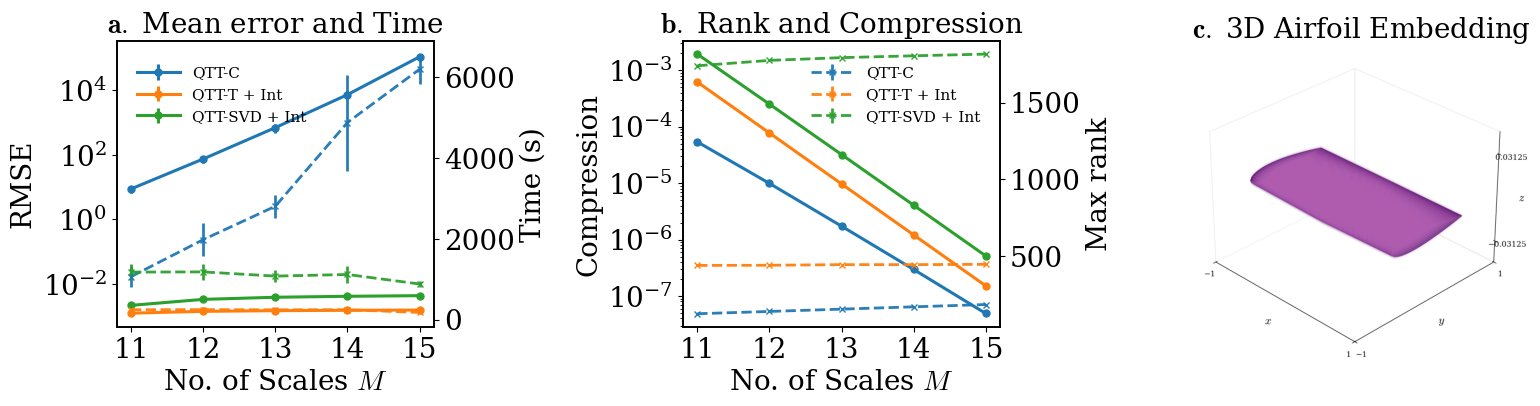

In [3]:
# three_panel_combined_formatted.py
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation

# ── Style: match your reference (fonts/line widths)
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 11,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

# ── Load data
records = []
with open('./data/3d_wing_c10.jsonl', 'r') as f:
    for ln in f:
        ln = ln.strip()
        if ln:
            records.append(json.loads(ln))
df = pd.DataFrame(records)

# ── Aggregate
stats = (
    df.groupby(['method','scale'])
      .agg(error_mean=('error','mean'),
           error_std =('error','std'),
           time_mean =('time','mean'),
           time_std  =('time','std'),
           rmax_mean =('rmax','mean'),
           rmax_std  =('rmax','std'),
           erank_mean=('erank','mean'),
           erank_std =('erank','std'))
      .reset_index()
)
stats['compression_mean'] = stats['erank_mean']
stats['compression_std']  = stats['erank_std']

# ── Pretty names
label_map = {
    'cross':        'QTT-C',
    'cross_int':    'QTT-C + Int',
    'qtt-tucker':   'QTT-T + Int',
    'qtt_tucker':   'QTT-T + Int',
    'svd_int':      'QTT-SVD + Int',
}
nice_name = lambda m: label_map.get(m, m)

# Keep 'cross', drop only 'cross_int'
stats = stats[stats['method'] != 'cross_int'].copy()
methods = stats['method'].unique().tolist()
colors  = sns.color_palette('tab10', n_colors=len(methods))
strip_suffix = lambda labs: [s.split('•')[0].strip() for s in labs]

# ── Figure layout (GridSpec like your reference)
os.makedirs('./plots', exist_ok=True)
fig = plt.figure(figsize=(18.0, 4.2))                  # close to your 14x4, a bit wider
gs  = GridSpec(1, 3, figure=fig, width_ratios=[1.25, 1.25, 1.25])
gs.update(left=0.055, right=0.965, bottom=0.22, top=0.90, wspace=0.12)  # tighter gaps

# ── (a) Error (log) & Time (right)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = ax1.twinx()

for i, m in enumerate(methods):
    d = stats[stats['method'] == m].sort_values('scale')
    lbl = nice_name(m)
    ax1.errorbar(d['scale'], d['error_mean'], yerr=d['error_std'],
                 marker='o', linestyle='-', color=colors[i],
                 label=f'{lbl} • error', capsize=0, linewidth=2.2, markersize=5)
    ax2.errorbar(d['scale'], d['time_mean'],  yerr=d['time_std'],
                 marker='x', linestyle='--', color=colors[i], alpha=0.95,
                 label=f'{lbl} • time', capsize=0, linewidth=2.0, markersize=5)

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_xlabel('No. of Scales $M$')
ax1.set_ylabel('RMSE')
ax2.set_ylabel('Time (s)')
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
ax1.set_title(r"$\mathbf{a.}$ Mean error and Time", pad=6)

# Slightly wider than square
try:
    ax1.set_box_aspect(0.9)
except Exception:
    pass

# Legend: solid lines (error) only
h, l = ax1.get_legend_handles_labels()
ax1.legend(h, strip_suffix(l), frameon=False, loc="upper left",
           bbox_to_anchor=(0.02, 0.96), handlelength=2.8, labelspacing=0.5)

# ── (b) Compression (log) & Max rank (right)
ax3 = fig.add_subplot(gs[0, 1])
ax4 = ax3.twinx()

for i, m in enumerate(methods):
    d = stats[stats['method'] == m].sort_values('scale')
    lbl = nice_name(m)
    ax3.errorbar(d['scale'], d['compression_mean'], yerr=d['compression_std'],
                 marker='o', linestyle='-', color=colors[i],
                 label=f'{lbl} • compression', capsize=0, linewidth=2.2, markersize=5)
    ax4.errorbar(d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
                 marker='x', linestyle='--', color=colors[i], alpha=0.95,
                 label=f'{lbl} • max rank', capsize=0, linewidth=2.0, markersize=5)

ax3.set_yscale('log')
ax3.yaxis.set_major_formatter(LogFormatterSciNotation())
ax3.set_xlabel('No. of Scales $M$')
ax3.set_ylabel('Compression')
ax4.set_ylabel('Max rank')
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))
ax3.set_title(r"$\mathbf{b.}$ Rank and Compression", pad=6)

try:
    ax3.set_box_aspect(0.9)
except Exception:
    pass

# Legend: dashed lines (max rank) only
hr, lr = ax4.get_legend_handles_labels()
ax4.legend(hr, strip_suffix(lr), frameon=False, loc="upper right",
           bbox_to_anchor=(0.98, 0.96), handlelength=2.8, labelspacing=0.5)

# ── (c) 3D embedding image
ax_img = fig.add_subplot(gs[:, 2])
# --- Custom panel (c) size/position (figure fractions: [left, bottom, width, height]) ---
box = ax_img.get_position()  # current [x0, y0, w, h]
# Example: make it wider and taller while nudging left a bit so it stays inside the figure
new_box = [box.x0 - 0.04, box.y0 - 0.08, box.width * 1.1, box.height*1.1 ]
ax_img.set_position(new_box)

img = plt.imread('./plots/3d_embedding.png')  # ensure this path/file exists
ax_img.imshow(img)
ax_img.set_axis_off()
ax_img.set_title(r"$\mathbf{c.}$ 3D Airfoil Embedding", pad=4)



# Thicken spines for plots
for ax in (ax1, ax2, ax3, ax4):
    for s in ax.spines.values(): 
        s.set_linewidth(1.2)

# ── Save
fig.savefig('./plots/3d_wing_three_panel.pdf', bbox_inches='tight', facecolor='white')
fig.savefig('./plots/3d_wing_three_panel.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()


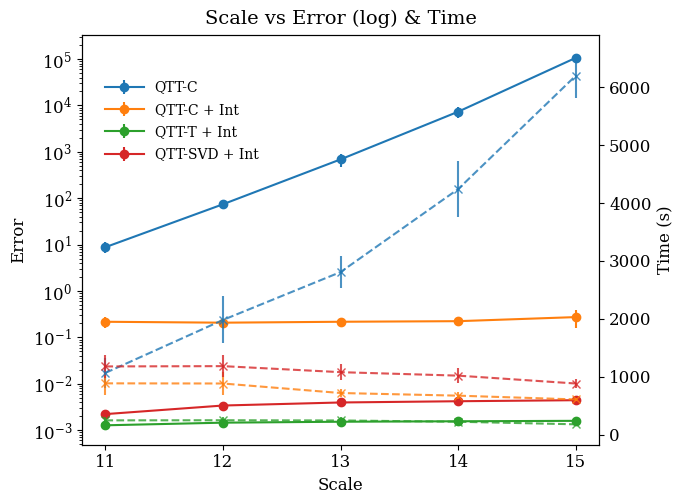

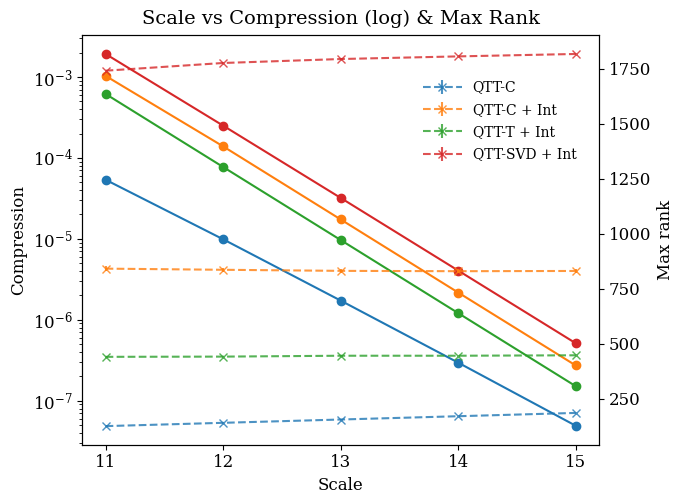

In [36]:
# save_two_panels_separately_labels_like_original.py
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation

# LaTeX-ish font
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# --- Load ---
records = []
with open('./data/3d_wing_c10.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if line:
            records.append(json.loads(line))
df = pd.DataFrame(records)

# --- Aggregate (mean ± std) ---
stats = (
    df.groupby(['method', 'scale'])
      .agg(error_mean=('error','mean'),
           error_std =('error','std'),
           time_mean =('time','mean'),
           time_std  =('time','std'),
           rmax_mean =('rmax','mean'),
           rmax_std  =('rmax','std'),
           erank_mean=('erank','mean'),
           erank_std =('erank','std'))
      .reset_index()
)

# Alias "erank" as "compression"
stats['compression_mean'] = stats['erank_mean']
stats['compression_std']  = stats['erank_std']

# Pretty labels for methods
label_map = {
    'cross':        'QTT-C',
    'cross_int':    'QTT-C + Int',
    'qtt-tucker':   'QTT-T + Int',
    'qtt_tucker':   'QTT-T + Int',   # just in case
    'svd_int':      'QTT-SVD + Int',
}
def nice_name(m): return label_map.get(m, m)

methods = stats['method'].unique()
colors  = sns.color_palette('tab10', n_colors=len(methods))

def strip_suffix(labels):
    # "Name • error/time/..." -> "Name"
    return [lab.split('•')[0].strip() for lab in labels]

os.makedirs('./plots', exist_ok=True)

# =========================
# (a) Error (log) & Time
# =========================
fig_a, ax1 = plt.subplots(figsize=(7.0, 5.2))
ax2 = ax1.twinx()

for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    name = nice_name(method)

    # Left axis: Error (solid)
    ax1.errorbar(
        d['scale'], d['error_mean'], yerr=d['error_std'],
        marker='o', linestyle='-', label=f'{name} • error',
        color=colors[i], zorder=3
    )
    # Right axis: Time (dashed)
    ax2.errorbar(
        d['scale'], d['time_mean'], yerr=d['time_std'],
        marker='x', linestyle='--', label=f'{name} • time',
        color=colors[i], alpha=0.8, zorder=2
    )

ax1.set_yscale('log')
ax1.yaxis.set_major_formatter(LogFormatterSciNotation())
ax1.set_xlabel('Scale', fontsize=12)
ax1.set_ylabel('Error', fontsize=12)
ax2.set_ylabel('Time (s)', fontsize=12)
ax1.set_title('Scale vs Error (log) & Time', pad=8, fontsize=14)
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

# ONE legend on the left figure, from SOLID (error) lines only
err_lines, err_labels = ax1.get_legend_handles_labels()
ax1.legend(
    err_lines, strip_suffix(err_labels),
    loc='upper left', bbox_to_anchor=(0.02, 0.92),
    frameon=False, fontsize=10, handlelength=2.8, labelspacing=0.6
)

fig_a.tight_layout()
fig_a.savefig('./plots/3d_wing_results_a.pdf', bbox_inches='tight', facecolor='white')
# fig_a.savefig('./plots/3d_wing_results_a.png', dpi=200, bbox_inches='tight', facecolor='white')

# =========================
# (b) Compression (log) & Max rank
# =========================
fig_b, ax3 = plt.subplots(figsize=(7.0, 5.2))
ax4 = ax3.twinx()

for i, method in enumerate(methods):
    d = stats[stats['method'] == method].sort_values('scale')
    name = nice_name(method)

    # Left axis: Compression (solid)
    ax3.errorbar(
        d['scale'], d['compression_mean'], yerr=d['compression_std'],
        marker='o', linestyle='-', label=f'{name} • compression',
        color=colors[i], zorder=3
    )
    # Right axis: Max rank (dashed)
    ax4.errorbar(
        d['scale'], d['rmax_mean'], yerr=d['rmax_std'],
        marker='x', linestyle='--', label=f'{name} • max rank',
        color=colors[i], alpha=0.8, zorder=2
    )

ax3.set_yscale('log')
ax3.yaxis.set_major_formatter(LogFormatterSciNotation())
ax3.set_xlabel('Scale', fontsize=12)
ax3.set_ylabel('Compression', fontsize=12)
ax4.set_ylabel('Max rank', fontsize=12)
ax3.set_title('Scale vs Compression (log) & Max Rank', pad=8, fontsize=14)
ax3.xaxis.set_major_locator(MaxNLocator(integer=True))

# ONE legend on the right figure, from DASHED (max-rank) lines only
rmax_lines, rmax_labels = ax4.get_legend_handles_labels()
ax4.legend(
    rmax_lines, strip_suffix(rmax_labels),
    loc='upper right', bbox_to_anchor=(0.98, 0.92),
    frameon=False, fontsize=10, handlelength=2.8, labelspacing=0.6
)

fig_b.tight_layout()
fig_b.savefig('./plots/3d_wing_results_b.pdf', bbox_inches='tight', facecolor='white')
# fig_b.savefig('./plots/3d_wing_results_b.png', dpi=200, bbox_inches='tight', facecolor='white')

plt.show()


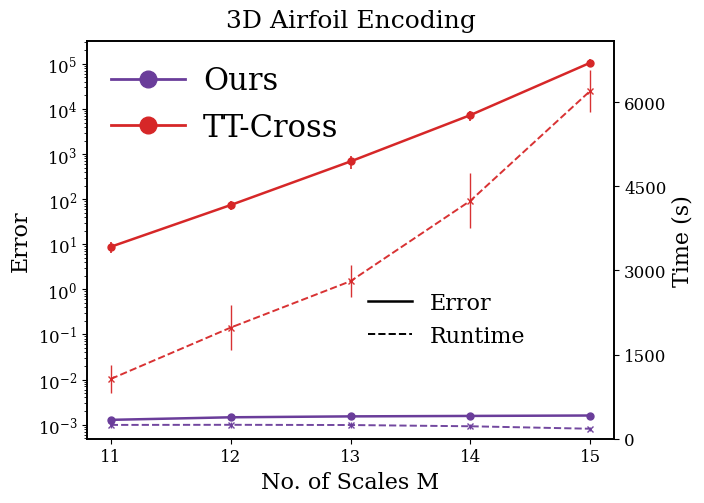

In [32]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LogFormatterSciNotation
from matplotlib.lines import Line2D

# LaTeX-ish font
plt.rc('font', family='serif', size=12)
plt.rc('mathtext', fontset='cm')

# --- Load ---
records = []
with open('./data/3d_wing_c10.jsonl', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        records.append(json.loads(line))
df = pd.DataFrame(records)

# --- Aggregate (mean ± std) ---
agg = (
    df.groupby(['method', 'scale'])
      .agg(error_mean=('error','mean'),
           error_std =('error','std'),
           time_mean =('time','mean'),
           time_std  =('time','std'))
      .reset_index()
)

# --- Pick only the two methods of interest ---
# Ours = qtt-tucker/qtt_tucker (purple), QTT-Cross = cross (red)
method_specs = [
    (['qtt-tucker', 'qtt_tucker'], 'Ours',       '#6a3d9a'),  # purple
    (['cross'],                    'QTT-Cross',  '#d62728'),  # red
]

plot_rows = []
for keys, label, color in method_specs:
    d = agg[agg['method'].isin(keys)].copy()
    if not d.empty:
        d['label'] = label
        d['color'] = color
        plot_rows.append(d)

if not plot_rows:
    raise RuntimeError("Neither 'qtt-tucker/qtt_tucker' nor 'cross' found in the data.")

plot_df = pd.concat(plot_rows, ignore_index=True)

# --- Figure: Error (left, log) & Time (right, LINEAR) ---
fig, ax_err = plt.subplots(figsize=(7.2, 5.2))
ax_time = ax_err.twinx()

for (label, color), g in plot_df.groupby(['label', 'color']):
    g = g.sort_values('scale')

    # Left axis: Error (solid)
    ax_err.errorbar(
        g['scale'], g['error_mean'], yerr=g['error_std'],
        marker='o', linestyle='-', color=color,
        capsize=0, elinewidth=1.2, linewidth=1.8, markersize=5
    )

    # Right axis: Time (dashed) — LINEAR
    ax_time.errorbar(
        g['scale'], g['time_mean'], yerr=g['time_std'],
        marker='x', linestyle='--', color=color, alpha=0.95,
        capsize=0, elinewidth=1.0, linewidth=1.4, markersize=5
    )

# Axes formatting
ax_err.set_yscale('log')
ax_err.yaxis.set_major_formatter(LogFormatterSciNotation())
ax_err.xaxis.set_major_locator(MaxNLocator(integer=True))

# --- Time axis: LINEAR + more ticks ---
# Compute padded limits from data (including error bars)
t_mean = plot_df['time_mean'].to_numpy()
t_std  = np.nan_to_num(plot_df['time_std'].to_numpy(), nan=0.0)

t_lo = float(np.nanmin(t_mean - t_std))
t_hi = float(np.nanmax(t_mean + t_std))
if not np.isfinite(t_lo) or not np.isfinite(t_hi):
    t_lo, t_hi = 0.0, 1.0
if t_lo == t_hi:
    t_hi = t_lo + 1.0

pad = 0.08 * (t_hi - t_lo)
ax_time.set_ylim(max(0.0, t_lo - pad), t_hi + pad)
ax_time.yaxis.set_major_locator(MaxNLocator(nbins=6))  # more nicely spaced ticks

# Labels & title
ax_err.set_xlabel('No. of Scales M', fontsize=16)
ax_err.set_ylabel('Error', fontsize=16)
ax_time.set_ylabel('Time (s)', fontsize=16)
ax_err.set_title('3D Airfoil Encoding', fontsize=18, pad=10)

# --- Legend 1: methods (colored line + dot) ---
COLOR_OURS  = '#6a3d9a'
COLOR_CROSS = '#d62728'
legend_handles = [
    Line2D([0], [0], linestyle='-', color=COLOR_OURS,
           marker='o', markerfacecolor=COLOR_OURS, markeredgecolor=COLOR_OURS,
           linewidth=2.0, markersize=12, label='Ours'),
    Line2D([0], [0], linestyle='-', color=COLOR_CROSS,
           marker='o', markerfacecolor=COLOR_CROSS, markeredgecolor=COLOR_CROSS,
           linewidth=2.0, markersize=12, label='TT-Cross'),
]
leg_methods = ax_err.legend(
    handles=legend_handles,
    frameon=False, fontsize=22, handlelength=2.4, handletextpad=0.6,
    borderpad=0.3, loc='best'
)

# --- Legend 2: line-style key (mid-right) ---
style_handles = [
    Line2D([0], [0], color='k', linestyle='-',  linewidth=1.8, label='Error'),
    Line2D([0], [0], color='k', linestyle='--', linewidth=1.4, label='Runtime'),
]
leg_styles = ax_err.legend(
    handles=style_handles, frameon=False, fontsize=16,
    loc='center right', bbox_to_anchor=(0.87, 0.3), title_fontsize=11
)
ax_err.add_artist(leg_methods)

# Spines
for ax in (ax_err, ax_time):
    for s in ax.spines.values():
        s.set_linewidth(1.2)

fig.tight_layout()

# Save (optional)
os.makedirs('./plots', exist_ok=True)
fig.savefig('./plots/error_time_Ours_vs_QTT-Cross_linearTime.pdf',
            bbox_inches='tight', facecolor='white')
fig.savefig('./plots/error_time_Ours_vs_QTT-Cross_linearTime.png',
            dpi=200, bbox_inches='tight', facecolor='white')

plt.show()


# Turbulence

## individual metrics

-0.4221034917164266


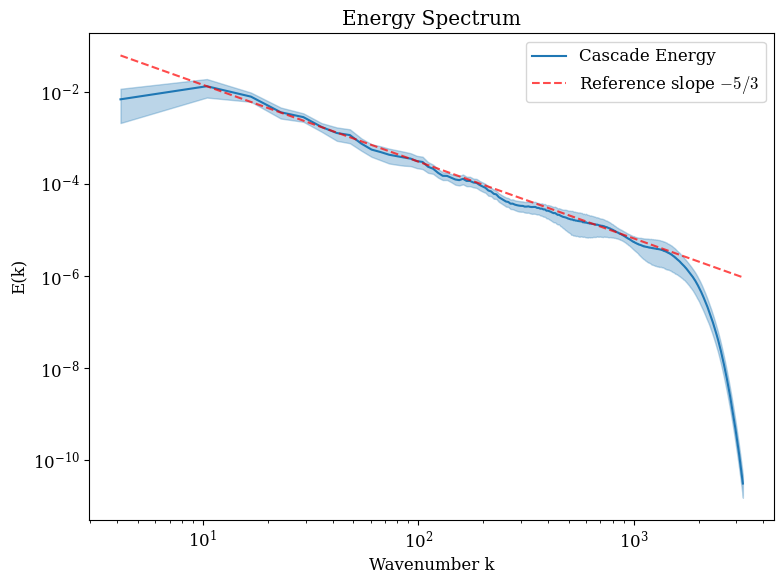

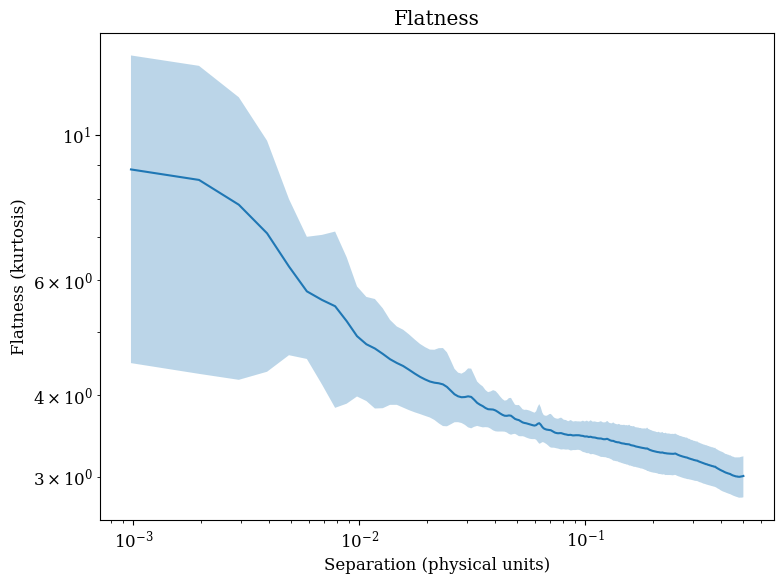

'\n# 2) Scaling exponent of the energy spectrum\nscaling = np.log(E_mean) / np.log(k)\n# Error propagation: σ_S = σ_E / (E_mean * |ln(k)|)\nsigma_scaling = E_std / (E_mean * np.abs(np.log(k)))\n# Plot scaling exponent with error shading\nplt.figure(figsize=(8, 6))\nplt.plot(k, scaling, label=\'Scaling exponent\')\nplt.fill_between(k, scaling - sigma_scaling, scaling + sigma_scaling, alpha=0.3, label=\'±1σ error\')\nplt.title("Scaling Exponent of Energy Spectrum")\nplt.show()\n'

In [9]:
# Load previously saved data
df_energy    = pd.read_csv('./data/turbulence/energy_comb10_e12.csv')
df_flatness  = pd.read_csv('./data/turbulence/flatness_comb10_e12.csv')

# Drop rows where separation is NaN
# df_flatness = df_flatness.dropna(subset=['separation'])

# 1) Energy statistics: mean and std over runs at each k_center
energy_stats = df_energy.groupby('k_center')['E_k'].agg(['mean', 'std']).reset_index()
k      = energy_stats['k_center'].values
E_mean = energy_stats['mean'].values
E_std  = energy_stats['std'].values

# --- Linear fit on the window where 2 <= k <= 300 ---
# mask = (k >= 2) & (k <= 300)
# log_k_fit = np.log(k[mask])
# log_E_fit = np.log(E_mean[mask])
# slope, intercept, *_ = linregress(log_k_fit, log_E_fit)
# fit_line = np.exp(intercept + slope * np.log(k))  # for full overlay

# --- Reference line with slope -5/3 ---
k_ref = np.linspace(k.min(), k.max(), 200)
ref_slope = -5/3
# Choose reference level so that it matches roughly the curve height
ref_intercept = np.log(E_mean[ (k > 10) & (k < 400) ][0]) - ref_slope * np.log(k[(k > 10) & (k < 400)][0])
print(ref_intercept)
ref_line = np.exp(ref_intercept) * k_ref**(ref_slope)

# --- Plot ---
plt.figure(figsize=(8, 6))
plt.loglog(k, E_mean, label='Cascade Energy', color='tab:blue')
plt.fill_between(k, E_mean - E_std, E_mean + E_std, alpha=0.3, color='tab:blue')
# plt.loglog(k, fit_line, '--', color='red', alpha=0.5, label=f"Fit: slope = {slope:.2f}")
plt.loglog(k_ref, ref_line, '--', color='red', alpha=0.7, label=r"Reference slope $-5/3$")

plt.xlabel("Wavenumber k")
plt.ylabel("E(k)")
plt.title("Energy Spectrum")
plt.legend()
plt.tight_layout()
plt.savefig("./plots/energy.pdf", format='pdf')
plt.show()

# 3) Flatness statistics: mean and std over runs at each separation
flat_stats = df_flatness.groupby('separation')['flatness'].agg(['mean', 'std']).reset_index()
s       = flat_stats['separation'].values
F_mean  = flat_stats['mean'].values
F_std   = flat_stats['std'].values

# Plot flatness vs separation in log-log space
plt.figure(figsize=(8, 6))
plt.loglog(s, F_mean, label='Cascade Flatness')
plt.fill_between(s, F_mean - F_std, F_mean + F_std, alpha=0.3)
plt.xlabel("Separation (physical units)")
plt.ylabel("Flatness (kurtosis)")
plt.title("Flatness")
#plt.legend()
plt.tight_layout()
plt.savefig("./plots/flatness.pdf", format='pdf')
plt.show()

"""
# 2) Scaling exponent of the energy spectrum
scaling = np.log(E_mean) / np.log(k)
# Error propagation: σ_S = σ_E / (E_mean * |ln(k)|)
sigma_scaling = E_std / (E_mean * np.abs(np.log(k)))
# Plot scaling exponent with error shading
plt.figure(figsize=(8, 6))
plt.plot(k, scaling, label='Scaling exponent')
plt.fill_between(k, scaling - sigma_scaling, scaling + sigma_scaling, alpha=0.3, label='±1σ error')
plt.title("Scaling Exponent of Energy Spectrum")
plt.show()
"""


## all plots


In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter, LogLocator, LogFormatterMathtext
from scipy.stats import linregress
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.image as mpimg

from pysciplottk import EasyPlotter

# ── Snapshot for panel (a)
image = mpimg.imread("snapshot_cube.png")

# ====== Original (QTT-I) ======
df = pd.read_csv("./data/turbulence/rqttV5c2_1em8_p.csv")
stats  = df.groupby("Dimension")["MaxRank"].agg(["mean", "std"]).reset_index()
stats2 = df.groupby("Dimension")["ERank"].agg(["mean", "std"]).reset_index()
M         = stats["Dimension"].values
chi_mean  = stats["mean"].values
chi_std   = stats["std"].values
erank_mean = stats2["mean"].values
erank_std  = stats2["std"].values

# χ fit (QTT-I)
slope, intercept, *_ = linregress(df["Dimension"], df["MaxRank"])

# Flatness (QTT-I)
df_flatness = pd.read_csv("./data/turbulence/qttflatness10_8.csv")
flat_stats = df_flatness.groupby("separation")["flatness"].agg(["mean", "std"]).reset_index()
s      = flat_stats["separation"].values
F_mean = flat_stats["mean"].values
F_std  = flat_stats["std"].values

# Energy (QTT-I)
df_energy = pd.read_csv("./data/turbulence/qttenergy10_c.csv")
energy_stats = df_energy.groupby("k_center")["E_k"].agg(["mean", "std"]).reset_index()
k     = energy_stats["k_center"].values
E_mea = energy_stats["mean"].values
E_std = energy_stats["std"].values

# ====== Combined (QTT-T) ======
df_c = pd.read_csv("./data/turbulence/rcg_200_10_e8_o2.csv")  # updated file
df_c = df_c[df_c["Dimension"] <= 12]

# χ stats + fit (QTT-T)
stats_c   = df_c.groupby("Dimension")["MaxRank"].agg(["mean","std"]).reset_index()
M_c        = stats_c["Dimension"].values
chi_mean_c = stats_c["mean"].values
chi_std_c  = stats_c["std"].values
slope_c, intercept_c, *_ = linregress(df_c["Dimension"], df_c["MaxRank"])

# Energy (QTT-T)
df_energy_c    = pd.read_csv("./data/turbulence/energy_comb10_e12.csv")
energy_stats_c = df_energy_c.groupby("k_center")["E_k"].agg(["mean","std"]).reset_index()
k_c     = energy_stats_c["k_center"].values
E_mea_c = energy_stats_c["mean"].values
E_std_c = energy_stats_c["std"].values

# Flatness (QTT-T)
df_flatness_c = pd.read_csv("./data/turbulence/flatness_comb10_e12.csv")
flat_stats_c = df_flatness_c.groupby("separation")["flatness"].agg(["mean","std"]).reset_index()
s_c      = flat_stats_c["separation"].values
F_mean_c = flat_stats_c["mean"].values
F_std_c  = flat_stats_c["std"].values

# ====== Power-law guides k^{-5/3} ======
ref_slope = -5/3
def power_guide(x, y, slope, lo=10, hi=400):
    x = np.asarray(x); y = np.asarray(y)
    mask = (x > max(lo, x.min()*1.5)) & (x < min(hi, x.max()/1.5))
    idx = np.where(mask)[0][0] if np.any(mask) else len(x)//2
    b = np.log(y[idx]) - slope*np.log(x[idx])
    xr = np.linspace(x.min(), x.max(), 200)
    yr = np.exp(b) * xr**slope
    return xr, yr

k_ref,   ref_line   = power_guide(k,   E_mea,   ref_slope)
k_ref_c, ref_line_c = power_guide(k_c, E_mea_c, ref_slope)

# ──────────────────────────────────────────────────────────────────────
# SIZE CONFIG (exactly as requested)
plotter = EasyPlotter("synthetic_results.pdf", "latex,revtex")
fig = plotter.wide_figure()
fig.set_size_inches(w=14.0, h=4)
gs = GridSpec(1, 3, figure=fig, width_ratios=[1.0, 1.0, 1.0])
gs.update(left=0.043, right=0.94, bottom=0.23, top=0.92, wspace=0.16)

plt.rcParams.update({
    "lines.linewidth": 2.5,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "legend.fontsize": 16,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
})

axs = [fig.add_subplot(gs[0, i]) for i in range(3)]

# ── (a) Energy spectrum ──────────────────────────────────────────────
# Curves
line_I,  = axs[0].loglog(k,   E_mea,   color="tab:blue",  label="QTT-I")
axs[0].fill_between(k, E_mea - E_std, E_mea + E_std, alpha=0.30, color="tab:blue")
line_T,  = axs[0].loglog(k_c, E_mea_c, color="tab:green", label="QTT-T")
axs[0].fill_between(k_c, E_mea_c - E_std_c, E_mea_c + E_std_c, alpha=0.22, color="tab:green")

# Two k^{-5/3} guides (no legend labels)
axs[0].loglog(k_ref,   ref_line,   "--", color="tab:red")
axs[0].loglog(k_ref_c, ref_line_c, "--", color="tab:purple")

# Keep legend for the two data curves only
axs[0].legend(handles=[line_I, line_T], frameon=False, loc="upper right")

# Lower-right in-axes label for the guides (two colored swatches + one text)
x0, x1 = 0.78, 0.84         # swatch start/end (axes coords)
yR, yP = 0.09, 0.04         # stacked rows near lower-right
axs[0].plot([x0, x1], [yR, yR], transform=axs[0].transAxes, color="tab:red", linestyle="--",   lw=2, clip_on=False)
axs[0].plot([x0, x1], [yP, yP], transform=axs[0].transAxes, color="tab:purple", lw=2, linestyle="--",clip_on=False)
axs[0].text(0.85, 0.057, r"$k^{-5/3}$", transform=axs[0].transAxes,
            ha="left", va="center", fontsize=12, color="0.15")

axs[0].set_xlabel(r"$k = \sqrt{k_x^2 + k_y^2 + k_z^2}$")
axs[0].set_title(r"\textbf{a.} Energy Spectrum $E(k)$")


# Insert the snapshot image EXACTLY like your working example (after plotting)
inset_ax = inset_axes(
    axs[0],
    width="55%",
    height="55%",
    loc="lower left",
    bbox_to_anchor=(-0.1, -0.02, 1.1, 1.1),
    bbox_transform=axs[0].transAxes,
)
inset_ax.imshow(image)
inset_ax.axis("off")

# ── (b) Flatness ─────────────────────────────────────────────────────
axs[1].loglog(s,   F_mean,   color="tab:blue",  label="QTT-I")
axs[1].fill_between(s, F_mean - F_std, F_mean + F_std, alpha=0.30, color="tab:blue")
axs[1].loglog(s_c, F_mean_c, color="tab:green", label="QTT-T")
axs[1].fill_between(s_c, F_mean_c - F_std_c, F_mean_c + F_std_c, alpha=0.22, color="tab:green")

axs[1].set_xlabel(r"Separation $r$")
axs[1].axhline(y=min(F_mean.min(), F_mean_c.min()), color="black", linestyle="--",
               alpha=0.7, label=r"zero-intermittency")
axs[1].set_title(r"\textbf{b.} Flatness (kurtosis)")
axs[1].legend(frameon=False, loc="upper right")
for axis in [axs[1].yaxis]:
    axis.set_major_formatter(FuncFormatter(lambda y, _: "{:g}".format(y)))
    axis.set_minor_formatter(FuncFormatter(lambda y, _: "{:g}".format(y)))

# ── (c) χ vs M with BOTH compressions ───────────────────────────────
# χ points (no labels)
axs[2].errorbar(M,  chi_mean,  yerr=chi_std,  fmt="o", color="tab:blue")
axs[2].errorbar(M_c, chi_mean_c, yerr=chi_std_c, fmt="s", color="tab:green")

# χ slope lines + CENTER-TOP text labels (no bullets/lines)
axs[2].plot(M,  intercept + slope*M,   "--", color="crimson")
axs[2].plot(M_c, intercept_c + slope_c*M_c, "--", color="tab:olive")
axs[2].text(0.50, 0.96, rf"$\chi \propto {slope:.1f}M$ (QTT\!-\!I)",
            transform=axs[2].transAxes, ha="center", va="top",
            color="crimson", fontsize=13)
axs[2].text(0.50, 0.88, rf"$\chi \propto {slope_c:.1f}M$ (QTT\!-\!T)",
            transform=axs[2].transAxes, ha="center", va="top",
            color="tab:olive", fontsize=13)

# Compression (right axis)
comp_ratio     = (3 * M  * erank_mean**2) / (2 ** (3 * M))
comp_ratio_std = (3 * M  * erank_std**2)  / (2 ** (3 * M))
comp_I    = comp_ratio * 100.0
comp_I_lo = np.clip((comp_ratio - comp_ratio_std) * 100.0, 1e-12, None)
comp_I_hi = (comp_ratio + comp_ratio_std) * 100.0

comp_stats = df_c.groupby("Dimension")["compression"].agg(["mean","std"]).reset_index()
Mc        = comp_stats["Dimension"].values
comp_T    = comp_stats["mean"].values
comp_Tstd = comp_stats["std"].values
if comp_T.max() <= 1.5:
    comp_T    = comp_T * 100.0
    comp_Tstd = comp_Tstd * 100.0
comp_T_lo = np.clip(comp_T - comp_Tstd, 1e-12, None)
comp_T_hi = comp_T + comp_Tstd

ax_r = axs[2].twinx()
ax_r.plot(M,  comp_I, "-o",  ms=4, color="tab:orange")
ax_r.fill_between(M,  comp_I_lo, comp_I_hi, color="tab:orange", alpha=0.12, linewidth=0)
ax_r.plot(Mc, comp_T, "-^",  ms=4, color="sienna")
ax_r.fill_between(Mc, comp_T_lo, comp_T_hi, color="sienna", alpha=0.10, linewidth=0)
ax_r.axhline(y=100, color="gray", linestyle="--", alpha=0.5, linewidth=1)

# Robust log limits; clamp to 1e-4 min (no 1e-10 ticks)
all_low  = np.array([comp_I_lo.min(), comp_T_lo.min(), 1e-4])
all_high = np.array([comp_I_hi.max(), comp_T_hi.max(), 100.0])
cmin = float(all_low.min())
cmax = float(all_high.max())
lo_dec = 10 ** np.floor(np.log10(cmin))
hi_dec = 10 ** np.ceil(np.log10(cmax))
ax_r.set_yscale("log")
ax_r.set_ylim(lo_dec, hi_dec)
ax_r.yaxis.set_major_locator(LogLocator(base=10))
ax_r.yaxis.set_major_formatter(LogFormatterMathtext(base=10))
ax_r.yaxis.set_minor_formatter(FuncFormatter(lambda *_: ""))

# Compression labels (CENTER-LEFT on right axis) using short colored line swatches
def label_with_line(ax, y_ax, color, text):
    x0, x1 = 0.05, 0.15
    ax.plot([x0, x1], [y_ax, y_ax], transform=ax.transAxes, color=color, lw=2, clip_on=False)
    ax.text(x1 + 0.02, y_ax, text, transform=ax.transAxes,
            ha="left", va="center", color="black", fontsize=11)

label_with_line(ax_r, 0.55, "tab:orange", "Comp. (\%) QTT-I")
label_with_line(ax_r, 0.45, "sienna",     "Comp. (\%) QTT-T")

# Titles/labels (no χ label on y-axis)
axs[2].set_title(r"\textbf{c.} TT Bond dimension ($\chi$)")
axs[2].set_xlabel("No. of scales $M$")
# axs[2].set_ylabel(r"$\chi$")  # intentionally omitted
axs[2].xaxis.set_major_locator(plt.MaxNLocator(6, integer=True))
axs[2].yaxis.set_major_locator(plt.MaxNLocator(4))

# Final layout
gs.tight_layout(fig, pad=0.0)
plotter.save()


/tmp/ipykernel_1373610/3722067266.py:223: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  gs.tight_layout(fig, pad=0.0)
